In [6]:
# %pip install numpy
# %pip install pandas
# %pip install matplotlib
# %pip install seaborn
# %pip install plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
plt.style.use('default')
sns.set_palette("husl")


In [7]:
df = pd.read_csv('../data/weather_forecasting_dataset.csv')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2066 entries, 0 to 2065
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MinTemp        2066 non-null   float64
 1   MaxTemp        2066 non-null   float64
 2   Rainfall       2066 non-null   float64
 3   Evaporation    2066 non-null   float64
 4   Sunshine       2066 non-null   float64
 5   WindGustDir    2066 non-null   object 
 6   WindGustSpeed  2066 non-null   float64
 7   WindDir9am     2066 non-null   object 
 8   WindDir3pm     2066 non-null   object 
 9   WindSpeed9am   2066 non-null   float64
 10  WindSpeed3pm   2066 non-null   float64
 11  Humidity9am    2066 non-null   float64
 12  Humidity3pm    2066 non-null   float64
 13  Pressure9am    2066 non-null   float64
 14  Pressure3pm    2066 non-null   float64
 15  Cloud9am       2066 non-null   float64
 16  Cloud3pm       2066 non-null   float64
 17  Temp9am        2066 non-null   float64
 18  Temp3pm 

In [9]:
print("Dataset Overview:")
print(f"Total samples: {len(df)}")
print(f"Rain Tomorrow - Yes: {(df['RainTomorrow']=='Yes').sum()} ({(df['RainTomorrow']=='Yes').sum()/len(df)*100:.1f}%)")
print(f"Rain Tomorrow - No: {(df['RainTomorrow']=='No').sum()} ({(df['RainTomorrow']=='No').sum()/len(df)*100:.1f}%)")

print(f"\nRISK_MM statistics for rainy days:")
rainy = df[df['RainTomorrow']=='Yes']
print(f"Mean: {rainy['RISK_MM'].mean():.2f} mm")
print(f"Median: {rainy['RISK_MM'].median():.2f} mm")
print(f"Max: {rainy['RISK_MM'].max():.2f} mm")

Dataset Overview:
Total samples: 2066
Rain Tomorrow - Yes: 1166 (56.4%)
Rain Tomorrow - No: 900 (43.6%)

RISK_MM statistics for rainy days:
Mean: 3.89 mm
Median: 1.79 mm
Max: 40.06 mm


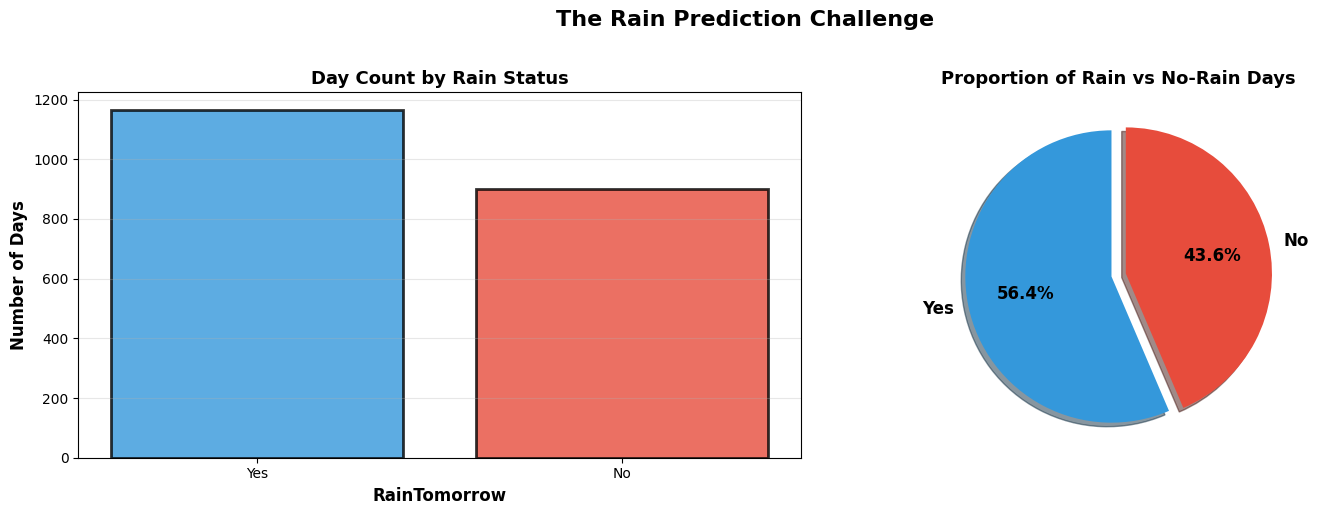

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('The Rain Prediction Challenge', 
             fontsize=16, fontweight='bold', y=1.02)

rain_counts = df['RainTomorrow'].value_counts()
colors = ['#3498db', '#e74c3c']

bars = axes[0].bar(rain_counts.index, rain_counts.values, 
                    color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[0].set_xlabel('RainTomorrow', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Days', fontsize=12, fontweight='bold')
axes[0].set_title('Day Count by Rain Status', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)


explode = (0.05, 0.05)
wedges, texts, autotexts = axes[1].pie(rain_counts.values, 
                                         labels=rain_counts.index,
                                         autopct='%1.1f%%',
                                         colors=colors,
                                         startangle=90,
                                         explode=explode,
                                         shadow=True,
                                         textprops={'fontsize': 12, 'fontweight': 'bold'})

axes[1].set_title('Proportion of Rain vs No-Rain Days', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


In [11]:
categories = ["Light (0-2mm)", "Mod (2-5mm)", "Heavy (5-10mm)", "V.Heavy(10-20)", "Storm (20mm+)"]
counts = [609, 283, 160, 81, 33]
colors = ['#B3D9FF', '#6BB6FF', '#3399FF', '#0066CC', '#003D7A']

fig = go.Figure(go.Bar(
    x=counts,
    y=categories,
    orientation='h',
    marker=dict(color=colors),
    text=counts,
    textposition='outside',
))

fig.update_layout(
    title="Rainfall Distribution on Rainy Days",
    xaxis_title="Days",
)
fig.update_traces(cliponaxis=False)
fig.show()

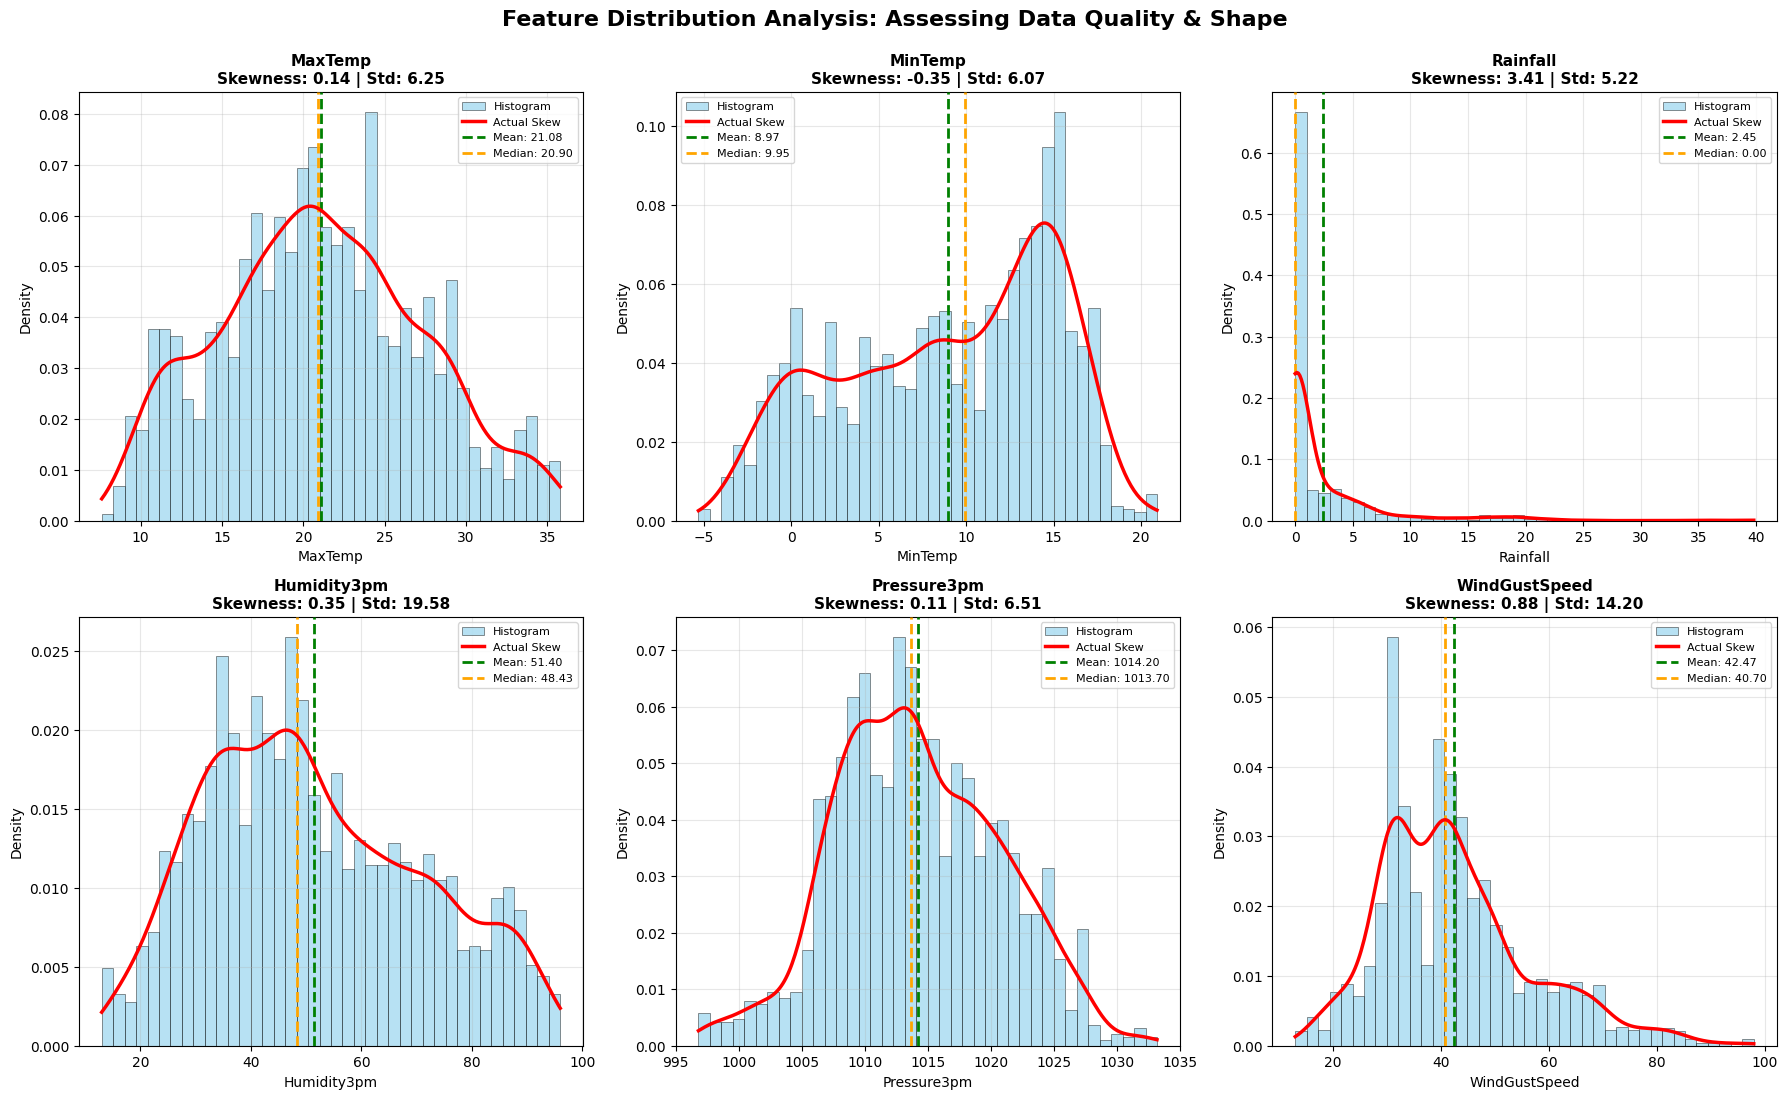

In [12]:
from scipy import stats


dist_features = ['MaxTemp', 'MinTemp', 'Rainfall', 'Humidity3pm', 'Pressure3pm', 'WindGustSpeed']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()

fig.suptitle('Feature Distribution Analysis: Assessing Data Quality & Shape', 
             fontsize=16, fontweight='bold', y=0.995)

for idx, feature in enumerate(dist_features):
    
    data_clean = df[feature].dropna()
    
    
    n, bins, patches = axes[idx].hist(data_clean, bins=40, alpha=0.6, 
                                       color='skyblue', edgecolor='black', 
                                       linewidth=0.5, density=True, label='Histogram')
    
    
    mean_val = data_clean.mean()
    median_val = data_clean.median()
    std_val = data_clean.std()
    skew_val = data_clean.skew()
    
    
    if len(data_clean) > 1:
        try:
            density = stats.gaussian_kde(data_clean)
            xs = np.linspace(data_clean.min(), data_clean.max(), 300)
            axes[idx].plot(xs, density(xs), 'r-', linewidth=2.5, 
                          label='Actual Skew', zorder=5)
        except:
            pass
    
    
    axes[idx].axvline(mean_val, color='green', linestyle='--', 
                     linewidth=2, label=f'Mean: {mean_val:.2f}', zorder=3)
    axes[idx].axvline(median_val, color='orange', linestyle='--', 
                     linewidth=2, label=f'Median: {median_val:.2f}', zorder=3)
    
    axes[idx].set_title(f'{feature}\nSkewness: {skew_val:.2f} | Std: {std_val:.2f}', 
                       fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(feature, fontsize=10)
    axes[idx].set_ylabel('Density', fontsize=10)
    axes[idx].legend(loc='best', fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Cloud3pm......................  0.549
Humidity3pm...................  0.445
Cloud9am......................  0.433
MinTemp.......................  0.355
Pressure9am................... -0.460
Pressure3pm................... -0.502
Sunshine...................... -0.513


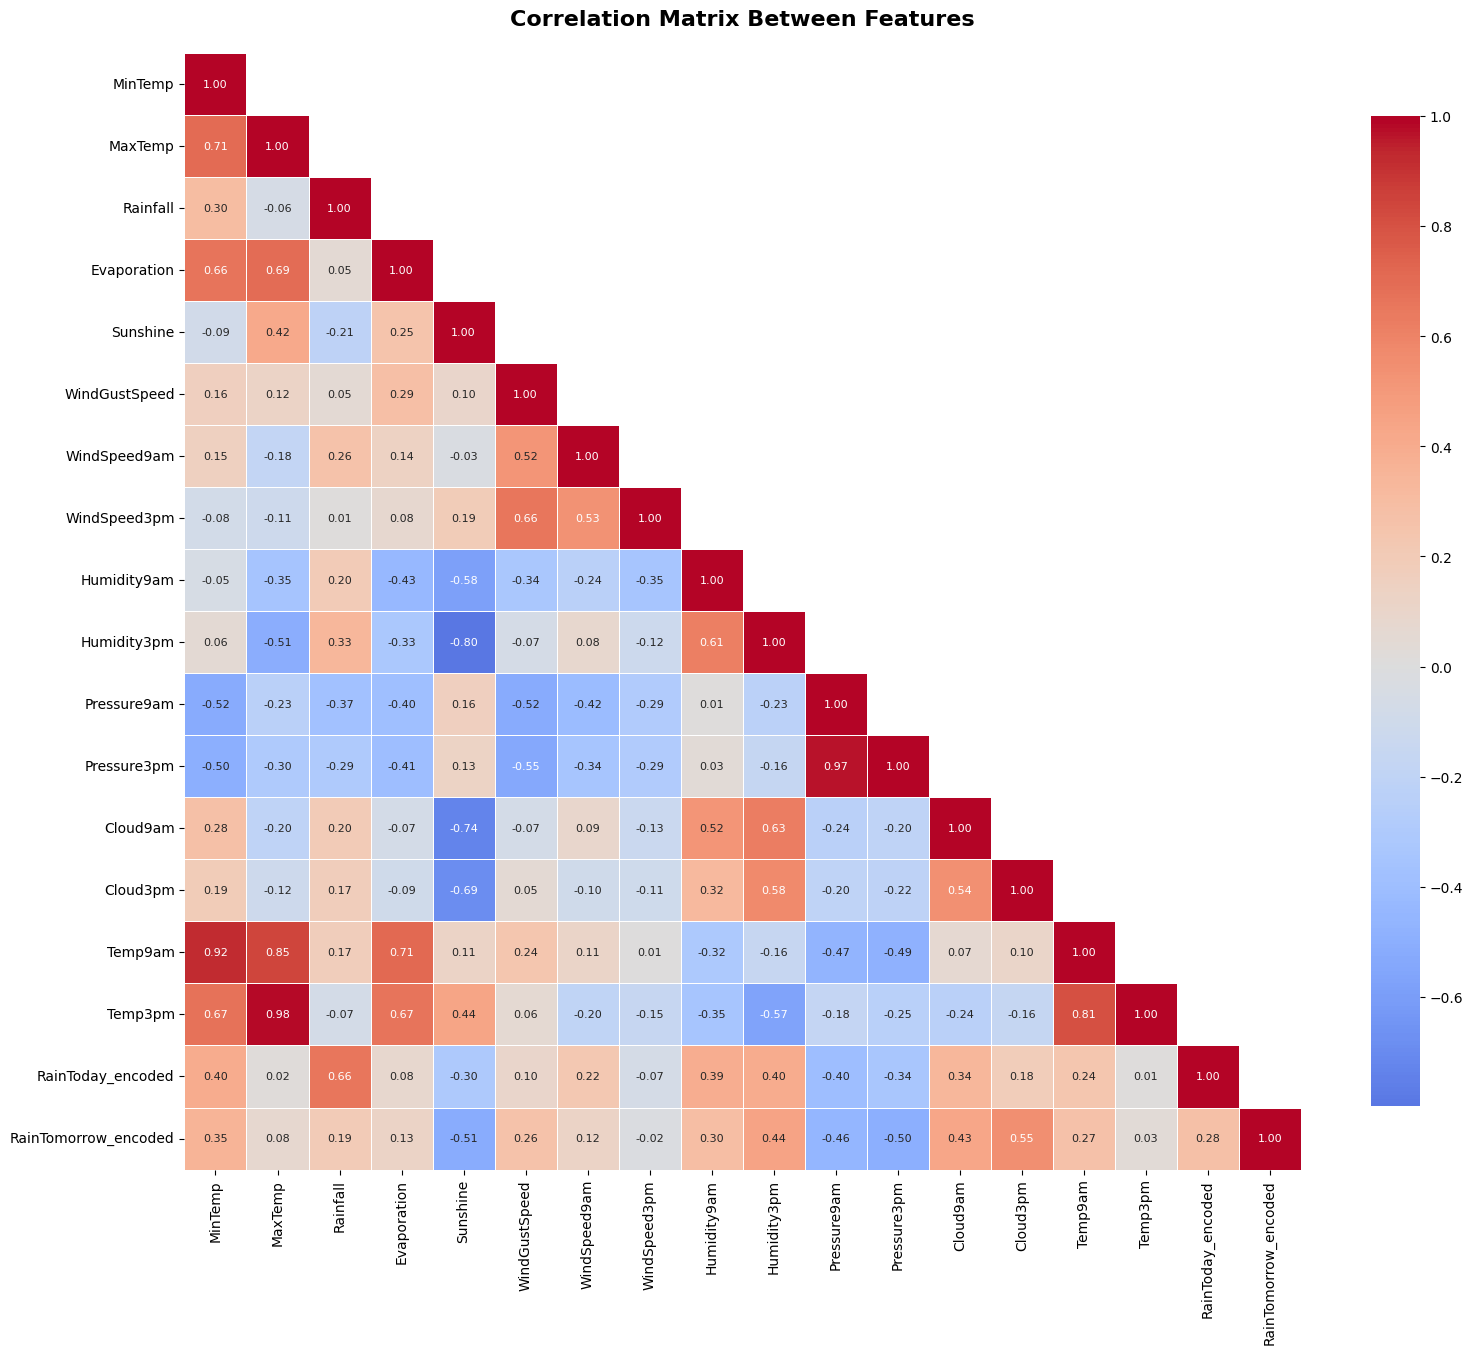

In [13]:
df['RainTomorrow_encoded'] = (df['RainTomorrow'] == 'Yes').astype(int)
df['RainToday_encoded'] = (df['RainToday'] == 'Yes').astype(int)


numerical_features = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
                     'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
                     'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
                     'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 
                     'RainToday_encoded', 'RainTomorrow_encoded']


corr_matrix = df[numerical_features].corr()


fig, ax = plt.subplots(figsize=(16, 14))


mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True, 
            linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={'size': 8})

ax.set_title('Correlation Matrix Between Features', 
             fontsize=16, fontweight='bold', pad=20)

target_corr = corr_matrix['RainTomorrow_encoded'].sort_values(ascending=False)
print("="*70)
for feature, corr_val in target_corr.items():
    if feature != 'RainTomorrow_encoded' and abs(corr_val) > 0.3:
        print(f"{feature:.<30} {corr_val:>6.3f}")

plt.tight_layout()
plt.show()

In [14]:
data = {
    "TempRange": ["0-10°C", "10-15°C", "15-20°C", "20-25°C", "25-30°C", "30+°C"],
    "No_Rain": [21, 220, 237, 173, 139, 110],
    "Rain": [31, 116, 285, 438, 247, 49],
    "Rain_Percentage": [59.6, 34.5, 54.6, 71.7, 64.0, 30.8]
}

df = pd.DataFrame(data)
fig = make_subplots(specs=[[{"secondary_y": True}]])


fig.add_trace(go.Bar(
    x=df['TempRange'],
    y=df['No_Rain'],
    name='No Rain',
    marker_color='#FFA500',
    cliponaxis=False
), secondary_y=False)


fig.add_trace(go.Bar(
    x=df['TempRange'],
    y=df['Rain'],
    name='Rain',
    marker_color='#1FB8CD',
    cliponaxis=False
), secondary_y=False)


fig.add_trace(go.Scatter(
    x=df['TempRange'],
    y=df['Rain_Percentage'],
    name='Rain %',
    mode='lines+markers+text',
    line=dict(color='#DB4545', width=3),
    marker=dict(size=8, color='#DB4545'),
    text=[f'{val}%' for val in df['Rain_Percentage']],
    textposition='top center',
    cliponaxis=False
), secondary_y=True)


fig.update_layout(
    title='Temp & Rain Probability',
    barmode='group',
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.05,
        xanchor='center',
        x=0.5
    )
)


fig.update_xaxes(title_text='Temp Range')
fig.update_yaxes(title_text='Count of Days', secondary_y=False)
fig.update_yaxes(title_text='Rain %', secondary_y=True)

fig.show()

In [15]:
data = {
    "Humidity_Range": ["0-40%", "40-60%", "60-80%", "80-100%"],
    "No_Rain": [446, 352, 99, 3],
    "Rain": [239, 372, 338, 217],
    "Rain_Percentage": [34.9, 51.4, 77.3, 98.6]
}

df = pd.DataFrame(data)


df['Total'] = df['No_Rain'] + df['Rain']
df['No_Rain_Pct'] = (df['No_Rain'] / df['Total']) * 100
df['Rain_Pct'] = (df['Rain'] / df['Total']) * 100


fig = go.Figure()


fig.add_trace(go.Bar(
    name='No Rain',
    x=df['Humidity_Range'],
    y=df['No_Rain_Pct'],
    marker_color='#FFA500',  # Orange
    text=[f'{val:.1f}%' for val in df['No_Rain_Pct']],
    textposition='inside',
    textfont=dict(size=14, color='white'),
    hovertemplate='<b>No Rain</b><br>Humidity: %{x}<br>Percentage: %{y:.1f}%<extra></extra>'
))

# Add Rain bars (blue)
fig.add_trace(go.Bar(
    name='Rain',
    x=df['Humidity_Range'],
    y=df['Rain_Pct'],
    marker_color='#1E90FF',  # Blue
    text=[f'{val:.1f}%' for val in df['Rain_Pct']],
    textposition='inside',
    textfont=dict(size=14, color='white'),
    hovertemplate='<b>Rain</b><br>Humidity: %{x}<br>Percentage: %{y:.1f}%<extra></extra>'
))


fig.update_layout(
    barmode='stack',
    title='Humidity Impact on Rain (3PM)',
    xaxis_title='Humidity at 3PM',
    yaxis_title='Percentage (%)',
    yaxis=dict(range=[0, 100]),
    legend=dict(orientation='h', yanchor='bottom', y=1.05, xanchor='center', x=0.5)
)

fig.update_traces(cliponaxis=False)

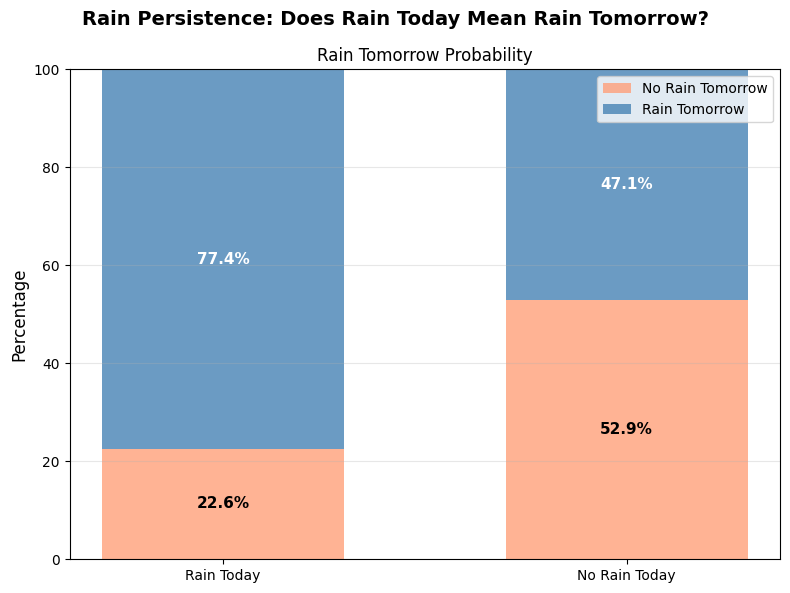

In [16]:
df = pd.read_csv('../data/weather_forecasting_dataset.csv')

persistence_table = pd.crosstab(df['RainToday'], df['RainTomorrow'], 
                                margins=True, margins_name='Total')


persistence_pct = pd.crosstab(df['RainToday'], df['RainTomorrow'], 
                              normalize='index') * 100


rain_today_yes = df[df['RainToday'] == 'Yes']['RainTomorrow'].value_counts()
rain_today_no = df[df['RainToday'] == 'No']['RainTomorrow'].value_counts()

x = ['Rain Today', 'No Rain Today']
yes_pct = [rain_today_yes['Yes']/rain_today_yes.sum()*100, 
           rain_today_no['Yes']/rain_today_no.sum()*100]
no_pct = [rain_today_yes['No']/rain_today_yes.sum()*100, 
          rain_today_no['No']/rain_today_no.sum()*100]


fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Rain Persistence: Does Rain Today Mean Rain Tomorrow?', 
             fontsize=14, fontweight='bold')

width = 0.6
ax.bar(x, no_pct, width, label='No Rain Tomorrow', 
       color='#FFA07A', alpha=0.8)
ax.bar(x, yes_pct, width, bottom=no_pct, label='Rain Tomorrow', 
       color='#4682B4', alpha=0.8)


for i, (n, y) in enumerate(zip(no_pct, yes_pct)):
    ax.text(i, n/2, f'{n:.1f}%', ha='center', va='center', 
            fontweight='bold', fontsize=11)
    ax.text(i, n + y/2, f'{y:.1f}%', ha='center', va='center', 
            fontweight='bold', fontsize=11, color='white')

ax.set_ylabel('Percentage', fontsize=12)
ax.set_title('Rain Tomorrow Probability', fontsize=12)
ax.legend()
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


rain_today_yes_total = (df['RainToday'] == 'Yes').sum()
rain_both = ((df['RainToday'] == 'Yes') & (df['RainTomorrow'] == 'Yes')).sum()
persistence_rate = rain_both / rain_today_yes_total * 100



Original dataset: 2066 rows
Rainy days (RISK_MM > 0): 984 rows


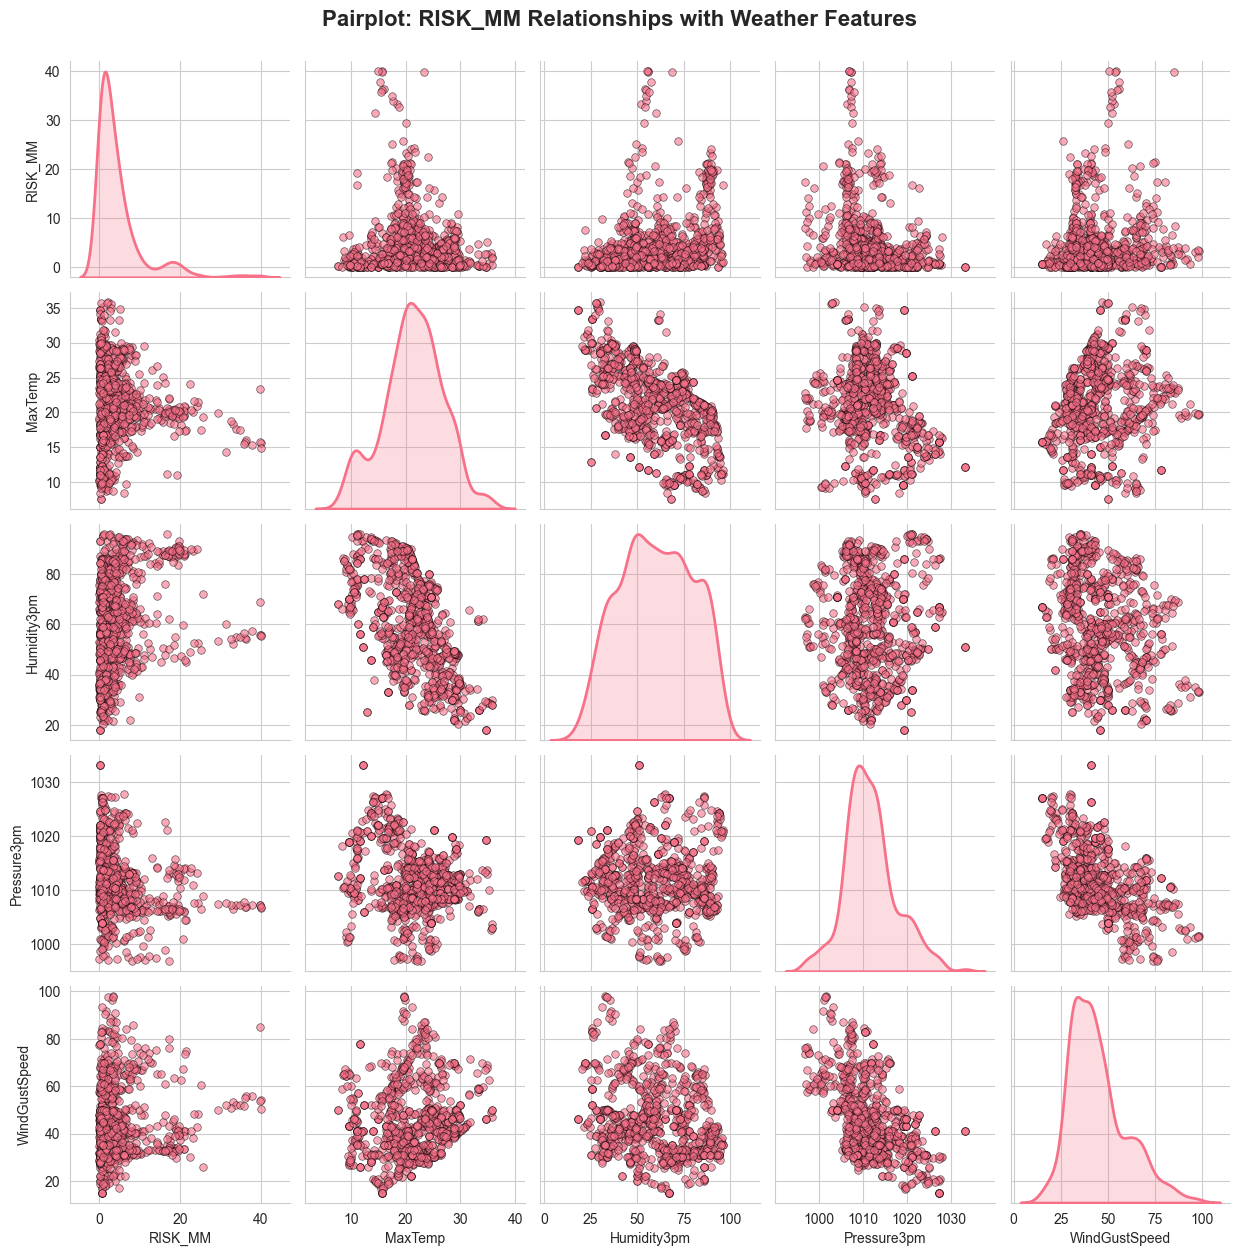

In [17]:
import warnings
warnings.filterwarnings("ignore")

rainy_days = df[df['RISK_MM'] > 0].copy()

print(f"Original dataset: {len(df)} rows")
print(f"Rainy days (RISK_MM > 0): {len(rainy_days)} rows")


pairplot_features = [
    'RISK_MM',           
    'MaxTemp',           
    'Humidity3pm',       
    'Pressure3pm',       
    'WindGustSpeed'      
]


pairplot_data = rainy_days[pairplot_features].dropna()


correlations = pairplot_data.corr()['RISK_MM'].sort_values(ascending=False)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 14)


pairplot = sns.pairplot(
    pairplot_data,
    diag_kind='kde',           
    plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'k', 'linewidth': 0.5},
    diag_kws={'shade': True, 'linewidth': 2}
)


pairplot.fig.suptitle('Pairplot: RISK_MM Relationships with Weather Features', 
                      fontsize=16, fontweight='bold', y=1.001)


plt.tight_layout()
plt.show()


In [18]:
df_processed = df.copy()
df_processed['RainTomorrow_encoded'] = (df_processed['RainTomorrow'] == 'Yes').astype(int)
df_processed['RainToday_encoded'] = (df_processed['RainToday'] == 'Yes').astype(int)
df_processed.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow,RainTomorrow_encoded,RainToday_encoded
0,17.5,29.9,0.0,6.6,8.8,E,43.0,E,ENE,13.0,...,1015.9,8.0,1.0,19.3,27.9,No,0.0,No,0,0
1,12.6,18.2,11.0,3.2,0.4,ENE,30.0,SSE,SSE,13.0,...,1011.0,7.0,8.0,16.3,16.8,Yes,0.2,No,0,1
2,5.3,21.0,0.0,4.6,6.3,WNW,26.0,SSW,NW,7.0,...,1023.3,7.0,2.0,12.0,20.4,No,0.0,No,0,0
3,7.6,16.1,2.8,5.6,10.6,SSE,50.0,SSE,ESE,20.0,...,1018.5,7.0,7.0,11.1,15.4,Yes,0.0,No,0,1
4,14.5,24.2,4.4,6.6,5.9,W,48.0,NNW,WNW,9.0,...,1006.8,8.0,5.0,15.8,22.6,Yes,11.0,Yes,1,1


In [19]:
df_processed['TempRange'] = df_processed['MaxTemp'] - df_processed['MinTemp']
df_processed['TempChange'] = df_processed['Temp3pm'] - df_processed['Temp9am']
df_processed['HumidityChange'] = df_processed['Humidity3pm'] - df_processed['Humidity9am']
df_processed['PressureChange'] = df_processed['Pressure3pm'] - df_processed['Pressure9am']
df_processed['WindSpeedChange'] = df_processed['WindSpeed3pm'] - df_processed['WindSpeed9am']
df_processed['CloudChange'] = df_processed['Cloud3pm'] - df_processed['Cloud9am']

df_processed['AvgTemp'] = (df_processed['Temp9am'] + df_processed['Temp3pm']) / 2
df_processed['AvgHumidity'] = (df_processed['Humidity9am'] + df_processed['Humidity3pm']) / 2
df_processed['AvgPressure'] = (df_processed['Pressure9am'] + df_processed['Pressure3pm']) / 2
df_processed['AvgWindSpeed'] = (df_processed['WindSpeed9am'] + df_processed['WindSpeed3pm']) / 2
df_processed['AvgCloud'] = (df_processed['Cloud9am'] + df_processed['Cloud3pm']) / 2

print(f"✓ Created {11} new engineered features")
print("  - Temperature range and changes")
print("  - Humidity, Pressure, WindSpeed, Cloud changes")
print("  - Average values for key metrics")
df_processed


✓ Created 11 new engineered features
  - Temperature range and changes
  - Humidity, Pressure, WindSpeed, Cloud changes
  - Average values for key metrics


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,TempChange,HumidityChange,PressureChange,WindSpeedChange,CloudChange,AvgTemp,AvgHumidity,AvgPressure,AvgWindSpeed,AvgCloud
0,17.500000,29.900000,0.000000,6.600000,8.800000,E,43.000000,E,ENE,13.000000,...,8.600000,-29.000000,-2.600000,-2.000000,-7.000000,23.600000,59.500000,1017.200000,12.000000,4.500000
1,12.600000,18.200000,11.000000,3.200000,0.400000,ENE,30.000000,SSE,SSE,13.000000,...,0.500000,-8.000000,1.000000,2.000000,1.000000,16.550000,77.000000,1010.500000,14.000000,7.500000
2,5.300000,21.000000,0.000000,4.600000,6.300000,WNW,26.000000,SSW,NW,7.000000,...,8.400000,-33.000000,-3.900000,0.000000,-5.000000,16.200000,60.500000,1025.250000,7.000000,4.500000
3,7.600000,16.100000,2.800000,5.600000,10.600000,SSE,50.000000,SSE,ESE,20.000000,...,4.300000,-19.000000,0.200000,8.000000,0.000000,13.250000,58.500000,1018.400000,24.000000,7.000000
4,14.500000,24.200000,4.400000,6.600000,5.900000,W,48.000000,NNW,WNW,9.000000,...,6.800000,-35.000000,-4.000000,8.000000,-3.000000,19.200000,77.500000,1008.800000,13.000000,6.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2061,9.200000,19.600000,0.600000,3.400000,10.400000,ENE,31.000000,SSE,NNW,4.000000,...,6.800000,-29.000000,-2.600000,3.000000,-3.000000,15.000000,56.500000,1021.000000,5.500000,5.500000
2062,13.726717,29.964653,1.025966,7.367505,8.148743,ESE,46.407879,WNW,SW,9.454783,...,8.752008,-46.801501,-4.254522,10.696811,-1.523452,24.209587,48.494559,1011.529437,14.803189,6.238274
2063,12.711237,17.366060,6.202533,2.769146,0.126502,NNW,42.876583,N,N,10.784020,...,0.477688,-2.079898,-3.777136,8.784020,0.030854,16.324131,92.558946,1008.727964,15.176031,7.984573
2064,9.200000,19.600000,0.600000,3.400000,10.400000,ENE,31.000000,SSE,NNW,4.000000,...,6.800000,-29.000000,-2.600000,3.000000,-3.000000,15.000000,56.500000,1021.000000,5.500000,5.500000


In [20]:
wind_dir_mapping = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
}
for col in ['WindGustDir', 'WindDir9am', 'WindDir3pm']:
    df_processed[f'{col}_degrees'] = df_processed[col].map(wind_dir_mapping)
    df_processed[f'{col}_sin'] = np.sin(np.radians(df_processed[f'{col}_degrees']))
    df_processed[f'{col}_cos'] = np.cos(np.radians(df_processed[f'{col}_degrees']))
    
print(f"✓ Encoded 3 wind direction features using cyclical encoding (sin/cos)")
print("  - WindGustDir, WindDir9am, WindDir3pm")
print("  - This preserves the circular nature of compass directions")
df_processed

✓ Encoded 3 wind direction features using cyclical encoding (sin/cos)
  - WindGustDir, WindDir9am, WindDir3pm
  - This preserves the circular nature of compass directions


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,AvgCloud,WindGustDir_degrees,WindGustDir_sin,WindGustDir_cos,WindDir9am_degrees,WindDir9am_sin,WindDir9am_cos,WindDir3pm_degrees,WindDir3pm_sin,WindDir3pm_cos
0,17.500000,29.900000,0.000000,6.600000,8.800000,E,43.000000,E,ENE,13.000000,...,4.500000,90.0,1.000000,6.123234e-17,90.0,1.000000,6.123234e-17,67.5,0.923880,3.826834e-01
1,12.600000,18.200000,11.000000,3.200000,0.400000,ENE,30.000000,SSE,SSE,13.000000,...,7.500000,67.5,0.923880,3.826834e-01,157.5,0.382683,-9.238795e-01,157.5,0.382683,-9.238795e-01
2,5.300000,21.000000,0.000000,4.600000,6.300000,WNW,26.000000,SSW,NW,7.000000,...,4.500000,292.5,-0.923880,3.826834e-01,202.5,-0.382683,-9.238795e-01,315.0,-0.707107,7.071068e-01
3,7.600000,16.100000,2.800000,5.600000,10.600000,SSE,50.000000,SSE,ESE,20.000000,...,7.000000,157.5,0.382683,-9.238795e-01,157.5,0.382683,-9.238795e-01,112.5,0.923880,-3.826834e-01
4,14.500000,24.200000,4.400000,6.600000,5.900000,W,48.000000,NNW,WNW,9.000000,...,6.500000,270.0,-1.000000,-1.836970e-16,337.5,-0.382683,9.238795e-01,292.5,-0.923880,3.826834e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2061,9.200000,19.600000,0.600000,3.400000,10.400000,ENE,31.000000,SSE,NNW,4.000000,...,5.500000,67.5,0.923880,3.826834e-01,157.5,0.382683,-9.238795e-01,337.5,-0.382683,9.238795e-01
2062,13.726717,29.964653,1.025966,7.367505,8.148743,ESE,46.407879,WNW,SW,9.454783,...,6.238274,112.5,0.923880,-3.826834e-01,292.5,-0.923880,3.826834e-01,225.0,-0.707107,-7.071068e-01
2063,12.711237,17.366060,6.202533,2.769146,0.126502,NNW,42.876583,N,N,10.784020,...,7.984573,337.5,-0.382683,9.238795e-01,0.0,0.000000,1.000000e+00,0.0,0.000000,1.000000e+00
2064,9.200000,19.600000,0.600000,3.400000,10.400000,ENE,31.000000,SSE,NNW,4.000000,...,5.500000,67.5,0.923880,3.826834e-01,157.5,0.382683,-9.238795e-01,337.5,-0.382683,9.238795e-01


In [21]:
classification_features = [
    'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
    'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
    'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
    'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm',

    'TempRange', 'TempChange', 'HumidityChange', 'PressureChange',
    'WindSpeedChange', 'CloudChange', 'AvgTemp', 'AvgHumidity',
    'AvgPressure', 'AvgWindSpeed', 'AvgCloud',

    'WindGustDir_sin', 'WindGustDir_cos',
    'WindDir9am_sin', 'WindDir9am_cos',
    'WindDir3pm_sin', 'WindDir3pm_cos',

    'RainToday_encoded'
]

regression_features = classification_features.copy()

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor

In [23]:
X_classification = df_processed[classification_features]
y_classification = df_processed['RainTomorrow_encoded']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_classification, y_classification, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_classification
)


scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

In [24]:
log_reg = LogisticRegression(
    class_weight='balanced', 
    max_iter=1000,
    random_state=42,
)

log_reg.fit(X_train_clf_scaled, y_train_clf)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [25]:
rainy_data = df_processed[df_processed['RainTomorrow_encoded'] == 1]
X_regression = rainy_data[regression_features]
y_regression = rainy_data['RISK_MM']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_regression, y_regression, 
    test_size=0.2, 
    random_state=42
)


scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

In [26]:
rf_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42

)
rf_reg.fit(X_train_reg_scaled, y_train_reg)

,n_estimators,100
,criterion,'squared_error'
,max_depth,15
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
def predict_rain_risk_simple(X_scaled, classifier, regressor):
    """Two-stage prediction for preprocessed data"""
    # Stage 1: Predict rain/no-rain
    rain_pred = classifier.predict(X_scaled)
    rain_prob = classifier.predict_proba(X_scaled)[:, 1]
    
    # Stage 2: Predict RISK_MM for rainy cases
    risk_mm = np.zeros(len(X_scaled))
    rain_indices = np.where(rain_pred == 1)[0]
    
    if len(rain_indices) > 0:
        risk_mm[rain_indices] = regressor.predict(X_scaled[rain_indices])
    
    return pd.DataFrame({
        'WillRainTomorrow': ['Yes' if r == 1 else 'No' for r in rain_pred],
        'RainProbability': rain_prob,
        'PredictedRISK_MM': risk_mm
    })

predictions = predict_rain_risk_simple(X_test_clf_scaled, log_reg, rf_reg)
predictions.head(20)

,WillRainTomorrow,RainProbability,PredictedRISK_MM
0,No,0.334368,0.000000
1,No,0.334368,0.000000
2,Yes,0.996945,1.247238
3,No,0.258849,0.000000
4,No,0.002158,0.000000
5,No,0.496731,0.000000
6,Yes,0.935303,0.942458
7,Yes,0.847126,2.635943
8,Yes,0.966343,0.748630
9,Yes,0.976746,10.213456


In [28]:
from sklearn.metrics import (

    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.model_selection import cross_validate

In [29]:
def evaluate_classification_model(model, X_train, y_train, X_test, y_test, model_name="Classification Model"):

    print("="*80)
    print(f"{model_name.upper()} - EVALUATION REPORT")
    print("="*80)


    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    print("\nCLASSIFICATION METRICS")
    print("-" * 80)

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)}

    for metric_name, metric_value in metrics.items():
        print(f"  {metric_name:.<40} {metric_value:.4f}")


    print("\nCONFUSION MATRIX ANALYSIS")
    print("-" * 80)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n  {'':20} Predicted Negative  |  Predicted Positive")
    print(f"  Actual Negative      {tn:>6}            |  {fp:>6}")
    print(f"  Actual Positive      {fn:>6}            |  {tp:>6}")

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ppv = tp / (tp + fp)
    npv = tn / (tn + fn)

    print(f"\n  Sensitivity (Recall):.................. {sensitivity:.4f}")
    print(f"  Specificity:........................... {specificity:.4f}")
    print(f"  Positive Predictive Value (Precision): {ppv:.4f}")
    print(f"  Negative Predictive Value:............. {npv:.4f}")


    print("\nCLASSIFICATION REPORT")
    print("-" * 80)
    print(classification_report(y_test, y_pred, digits=4))



    return metrics

clf_metrics = evaluate_classification_model(
        log_reg, 
        X_train_clf_scaled, y_train_clf,
        X_test_clf_scaled, y_test_clf,
        model_name="Logistic Regression - Rain Prediction"
    )


LOGISTIC REGRESSION - RAIN PREDICTION - EVALUATION REPORT

CLASSIFICATION METRICS
--------------------------------------------------------------------------------
  Accuracy................................ 0.8841
  Precision............................... 0.9043
  Recall.................................. 0.8889
  F1-Score................................ 0.8966

CONFUSION MATRIX ANALYSIS
--------------------------------------------------------------------------------

                       Predicted Negative  |  Predicted Positive
  Actual Negative         158            |      22
  Actual Positive          26            |     208

  Sensitivity (Recall):.................. 0.8889
  Specificity:........................... 0.8778
  Positive Predictive Value (Precision): 0.9043
  Negative Predictive Value:............. 0.8587

CLASSIFICATION REPORT
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

      

In [30]:
def evaluate_regression_model(model, X_train, y_train, X_test, y_test, model_name="Regression Model"):
    '''
    Comprehensive evaluation for regression models
    '''
    print("\n\n" + "="*80)
    print(f"{model_name.upper()} - EVALUATION REPORT")
    print("="*80)

    # Get predictions
    y_pred = model.predict(X_test)

    print("\nREGRESSION METRICS")
    print("-" * 80)

    cv_scoring = {
        'r2': 'r2',
        'neg_mse': 'neg_mean_squared_error',
        'neg_mae': 'neg_mean_absolute_error'
    }

    cv_results = cross_validate(
        model, X_train, y_train,
        cv=5, scoring=cv_scoring, return_train_score=True, n_jobs=-1
    )

    for metric in ['r2', 'neg_mse', 'neg_mae']:
        test_scores = cv_results[f'test_{metric}']
        train_scores = cv_results[f'train_{metric}']

        if 'neg' in metric:
            test_scores = -test_scores
            train_scores = -train_scores
            display_name = metric.replace('neg_', '').upper()
        else:
            display_name = metric.upper()

        print(f"\n  {display_name:.<20}")
        print(f"    Train: {train_scores.mean():.4f} (+/- {train_scores.std() * 2:.4f})")
        print(f"    Test:  {test_scores.mean():.4f} (+/- {test_scores.std() * 2:.4f})")

    print("\n PREDICTION vs ACTUAL ANALYSIS")
    print("-" * 80)

    correlation = np.corrcoef(y_test, y_pred)[0, 1]
    print(f"\n  Correlation (Predicted vs Actual):....... {correlation:.4f}")

    abs_errors = np.abs(y_test - y_pred)
    q25, q50, q75 = np.percentile(abs_errors, [25, 50, 75])

    print(f"\n  Error Distribution:")
    print(f"    25% of predictions have error ≤ {q25:.2f}")
    print(f"    50% of predictions have error ≤ {q50:.2f}")
    print(f"    75% of predictions have error ≤ {q75:.2f}")

    return ""


reg_metrics = evaluate_regression_model(
        rf_reg,
        X_train_reg_scaled, y_train_reg,
        X_test_reg_scaled, y_test_reg,
        model_name="Random Forest - RISK_MM Prediction"
    )



RANDOM FOREST - RISK_MM PREDICTION - EVALUATION REPORT

REGRESSION METRICS
--------------------------------------------------------------------------------

  R2..................
    Train: 0.9225 (+/- 0.0350)
    Test:  0.7672 (+/- 0.3166)

  MSE.................
    Train: 2.8404 (+/- 1.2179)
    Test:  7.7719 (+/- 7.0965)

  MAE.................
    Train: 0.8063 (+/- 0.1215)
    Test:  1.5309 (+/- 0.3154)

 PREDICTION vs ACTUAL ANALYSIS
--------------------------------------------------------------------------------

  Correlation (Predicted vs Actual):....... 0.7918

  Error Distribution:
    25% of predictions have error ≤ 0.51
    50% of predictions have error ≤ 0.95
    75% of predictions have error ≤ 1.65


In [ ]:
 
import joblib


joblib.dump(log_reg, 'model_classifier.pkl')  
joblib.dump(rf_reg, 'model_regressor.pkl')   


joblib.dump(scaler_clf, 'scaler_classifier.pkl')
joblib.dump(scaler_reg, 'scaler_regressor.pkl')


joblib.dump(classification_features, 'features_clf_order.pkl')

print("✅ All files exported successfully!")



✅ All files exported successfully!
